<a href="https://colab.research.google.com/github/lelenzasan/Somativa_ML/blob/main/Somativa_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Leonardo Henrique dos Santos
## Técnicas de Machine Learning (11100010577_20261_02)
## PUC-PR

# Trabalho de Machine Learning: Previsão de Pontos na NBA
Neste trabalho, vamos analisar um dataset com estatísticas de jogadores da NBA.
O objetivo principal é prever a quantidade de **Pontos (Points)** que um jogador marcou na temporada.

### Definição do Problema
O problema escolhido é de **Regressão**.
**Justificativa:** A variável alvo (target) que queremos prever é a coluna `Points` (Pontos), que é uma variável numérica contínua, representando um valor de contagem que pode variar enormemente. Algoritmos de regressão são os ideais para prever e projetar valores contínuos (ao contrário da classificação, que tentaria adivinhar uma categoria/classe).

## Configuração do Ambiente

In [ ]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import platform
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print('Versões das bibliotecas importadas:')

print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')
print("scikit-learn:", sklearn.__version__)
print(f'seaborn: {sns.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print("OS:", platform.platform())

Versões das bibliotecas importadas:
pandas: 2.2.2
numpy: 2.0.2
scikit-learn: 1.6.1
seaborn: 0.13.2
matplotlib: 3.10.0
OS: Linux-6.6.122+-x86_64-with-glibc2.35


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Carregamento e Verificação

In [ ]:
file_path = 'https://raw.githubusercontent.com/lelenzasan/Somativa_ML/refs/heads/main/nba_stats.csv?token=GHSAT0AAAAAAD64LFV6WSINHZANDKF6LDCA2RZW5KA'

df = pd.read_csv(file_path)

print(df.head())
print(df.info())

    Ano Posicao  Idade  Jogos  TrueShootingPercentage  FreeThrowRate  \
0  1950     G-F   31.0     63                   0.368          0.467   
1  1950      SG   29.0     49                   0.435          0.387   
2  1950      SF   25.0     67                   0.394          0.259   
3  1950       F   24.0     15                   0.312          0.395   
4  1950       F   24.0     13                   0.308          0.378   

   OffensiveWinShares  DefensiveWinShares  WinShares  FieldGoals  ...  \
0                -0.1                 3.6        3.5         144  ...   
1                 1.6                 0.6        2.2         102  ...   
2                 0.9                 2.8        3.6         174  ...   
3                -0.5                -0.1       -0.6          22  ...   
4                -0.5                -0.1       -0.6          21  ...   

   TwoPointFieldGoals  TwoPointFieldGoalAttempts  TwoPointFieldGoalPercentage  \
0                 144                        51

### Preparação dos Dados
Nesta etapa de preparação, realizaremos:
1. **Tratamento de Valores Nulos:** Iremos preencher os valores faltantes com a mediana.
2. **Remoção de Vazamento de Dados (Data Leakage):** Se usarmos colunas como `FieldGoals` (Cestas feitas) ou `FreeThrows` (Lances Livres) para prever os Pontos, o modelo apenas aprenderá a somar esses valores. Por isso, essas colunas diretas foram removidas para tornar o modelo realmente inteligente, forçando-o a prever os pontos baseado em métricas avançadas (como _Win Shares_ e eficiência).
3. **Encoding:** Iremos aplicar *One-Hot Encoding* na coluna categórica `Posicao`.

In [ ]:
# 1. Tratamento de nulos substituindo pela mediana das colunas numéricas
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# 2. Remover variáveis causadoras de vazamento de dados (que formam os pontos diretamente)
colunas_vazamento = ['FieldGoals', 'FieldGoalAttempts', 'TwoPointFieldGoals',
                     'TwoPointFieldGoalAttempts', 'FreeThrows', 'FreeThrowAttempts']
df = df.drop(columns=colunas_vazamento, errors='ignore')

# Definir Variáveis (X) e Alvo (y)
X = df.drop(columns=['Points', 'Ano', 'Posicao'])
y = df['Points']

# 3. Tratamento da variável categórica 'Posicao' com One-Hot Encoding
posicao_dummies = pd.get_dummies(df['Posicao'], prefix='Posicao')
X = pd.concat([X, posicao_dummies], axis=1)

print("Dimensão de X após preparação:", X.shape)

Dimensão de X após preparação: (24624, 36)


### Normalização e Extração de Atributos
Para melhorar o desempenho do algoritmo, faremos a **Normalização** dos dados utilizando o `StandardScaler` (colocando-os na mesma escala).
Em seguida, aplicaremos a técnica obrigatória de **Extração de Atributos** utilizando o **PCA (Análise de Componentes Principais)**. O PCA reduzirá a dimensionalidade da base, mantendo apenas os componentes que explicam 95% da variância original dos dados.

In [ ]:
# Normalização (Opcional, porém vital antes de aplicar o PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Extração de Atributos com PCA (mantendo 95% da informação estatística)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Número de atributos originais: {X.shape[1]}")
print(f"Número de componentes retidos após o PCA: {X_pca.shape[1]}")

Número de atributos originais: 36
Número de componentes retidos após o PCA: 27


### Divisão do Dataset
O dataset foi dividido da seguinte forma: **75% para a base de Treinamento** (onde o modelo vai aprender os padrões) e **25% para a base de Teste** (onde avaliaremos a real performance do modelo com dados inéditos).

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.25, random_state=42)

print(f"Tamanho da base de treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho da base de teste: {X_test.shape[0]} amostras")

Tamanho da base de treinamento: 18468 amostras
Tamanho da base de teste: 6156 amostras


### Treinamento do Modelo
Para realizar as previsões, escolhemos o modelo supervisionado **Random Forest Regressor** (da biblioteca *scikit-learn*). Trata-se de um modelo robusto que constrói múltiplas árvores de decisão. O treinamento ocorrerá exclusivamente na base de treino.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Instanciando o modelo
modelo = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Treinamento utilizando os 75% da base de treino
modelo.fit(X_train, y_train)

print("Treinamento finalizado com sucesso!")

Treinamento finalizado com sucesso!


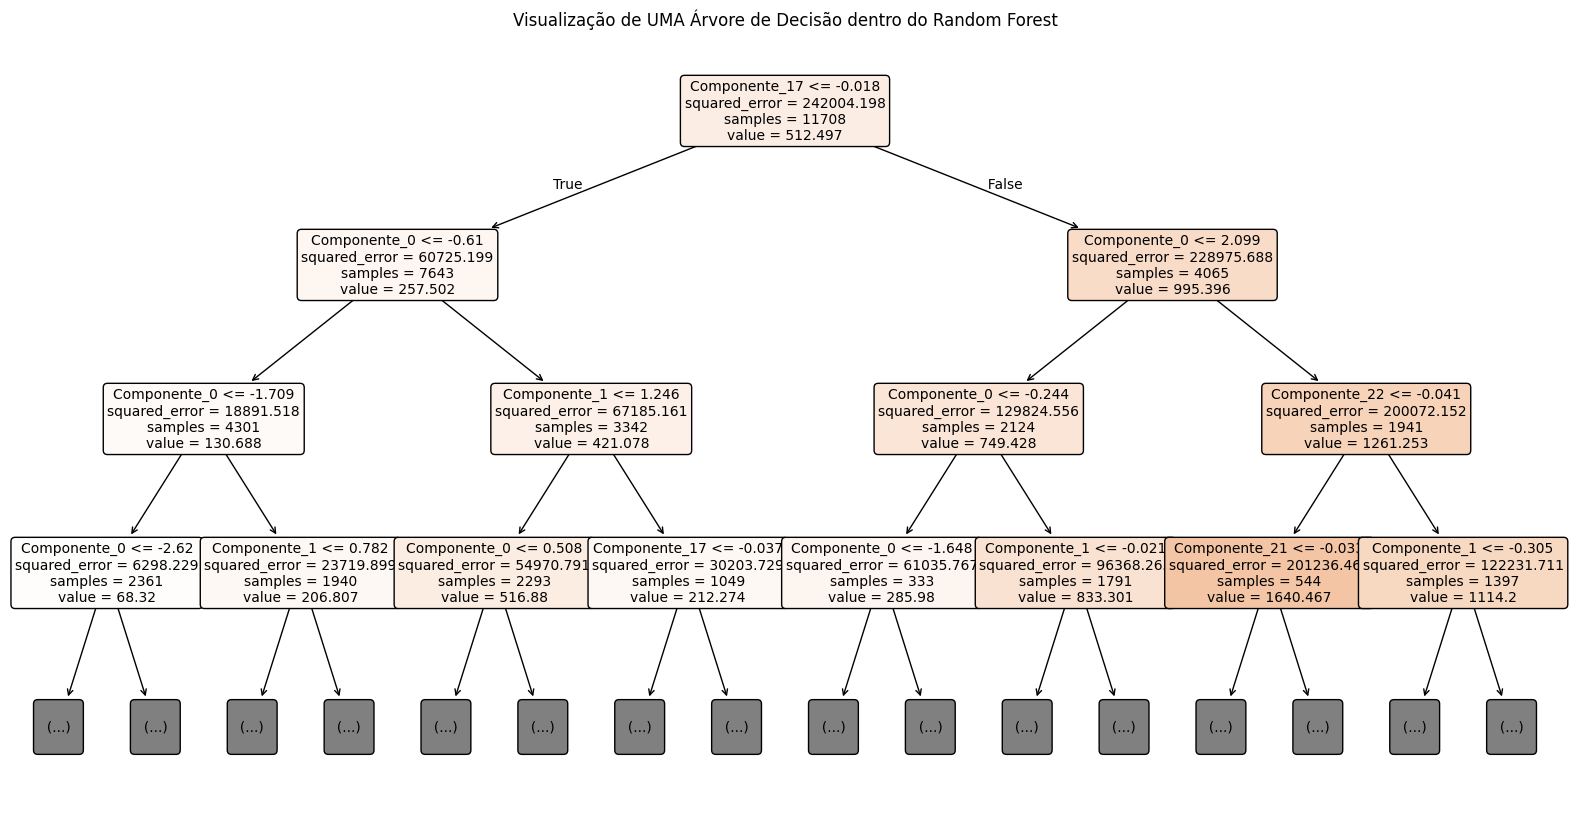

In [ ]:
from sklearn.tree import plot_tree

# Extrair a PRIMEIRA árvore da nossa floresta (índice 0)
primeira_arvore = modelo.estimators_[0]

# Gerar nomes para os componentes do PCA, já que X_test é um array numpy
pca_feature_names = [f'Componente_{i}' for i in range(X_test.shape[1])]

plt.figure(figsize=(20, 10))
# Plotamos a árvore (limitando a profundidade para 3, senão a imagem fica ilegível)
plot_tree(primeira_arvore,
          feature_names=pca_feature_names,
          filled=True,
          max_depth=3,
          fontsize=10,
          rounded=True)
plt.title("Visualização de UMA Árvore de Decisão dentro do Random Forest")
plt.show()

### Predição e Avaliação na Base de Teste
Abaixo, realizamos as previsões nos 25% de dados separados para teste. Utilizaremos o **Erro Absoluto Médio (MAE)** para descobrir quantos pontos de erro o modelo teve, em média, por jogador. Por fim, mostramos um comparativo direto de valores Reais vs. Previstos.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# Mostrando as predições para os 25% restantes da base
y_pred = modelo.predict(X_test)

# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erro Absoluto Médio (MAE): {mae:.2f} pontos")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

# Visualização das 10 primeiras amostras de teste
resultados = pd.DataFrame({
    'Valor Real (Pontos)': y_test[:10].values,
    'Valor Predito': np.round(y_pred[:10], 0)
})

print("\nComparação: Primeiras 10 predições da base de Teste:")
display(resultados)

Erro Absoluto Médio (MAE): 107.63 pontos
Coeficiente de Determinação (R²): 0.8889

Comparação: Primeiras 10 predições da base de Teste:


,Valor Real (Pontos),Valor Predito
0,191,212.0
1,79,39.0
2,158,169.0
3,228,251.0
4,444,767.0
5,774,1018.0
6,607,721.0
7,131,352.0
8,212,254.0
9,100,81.0


## Visualização dos erros de predição

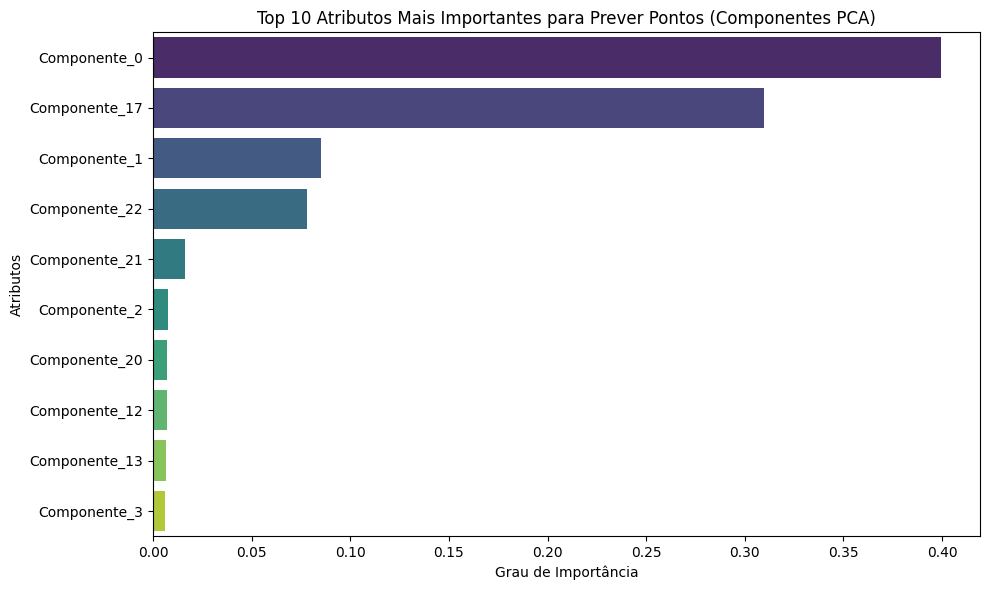

In [ ]:
# Extrair a importância das variáveis do modelo treinado
importancias = modelo.feature_importances_

nomes_features = [f'Componente_{i}' for i in range(X_test.shape[1])]

# Criar um DataFrame para facilitar a visualização
df_importancias = pd.DataFrame({'Atributo': nomes_features, 'Importância': importancias})
df_importancias = df_importancias.sort_values(by='Importância', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Atributo', data=df_importancias, palette='viridis', hue='Atributo', legend=False)
plt.title('Top 10 Atributos Mais Importantes para Prever Pontos (Componentes PCA)')
plt.xlabel('Grau de Importância')
plt.ylabel('Atributos')
plt.tight_layout()
plt.show()